In [2]:
import pandas as pd
import numpy as np

# 1. Gelecekteki uyarıyı (FutureWarning) engellemek için bu ayarı en başa ekle
pd.set_option('future.no_silent_downcasting', True)

# 2. low_memory=False ekleyerek Pandas'ın tüm dosyayı tek seferde analiz etmesini sağla.
# Bu, 'Mixed types' (karma tipler) uyarısını kesecektir.
df = pd.read_csv('perovskite_data.csv', low_memory=False)

# 3. "Unknown" verileri temizle
df.replace(['unknown', 'Unknown', 'n/a', '?', '-'], np.nan, inplace=True)

# 4. Uyarıda önerilen 'infer_objects' işlemini yaparak veri tiplerini netleştir
df = df.infer_objects(copy=False)

# Kontrol: Her şey yolunda mı?
print(f"Veri Seti Boyutu: {df.shape}")
print(df.head())

Veri Seti Boyutu: (42443, 410)
   Ref_ID  Ref_ID_temp Ref_name_of_person_entering_the_data  \
0       1            1                       Adam Hultqvist   
1       2            2                       Adam Hultqvist   
2       3            3                       Adam Hultqvist   
3       4            4                       Adam Hultqvist   
4       5            5                       Adam Hultqvist   

   Ref_data_entered_by_author     Ref_DOI_number Ref_lead_author  \
0                       False  10.1021/jp5126624    Sabba et al.   
1                       False  10.1021/jp5126624    Sabba et al.   
2                       False  10.1021/jp5126624    Sabba et al.   
3                       False  10.1021/jp5126624    Sabba et al.   
4                       False  10.1021/jp5126624    Sabba et al.   

  Ref_publication_date                          Ref_journal  \
0           2015-01-06  The Journal of Physical Chemistry C   
1           2015-01-06  The Journal of Physical Chemist

In [3]:
# Analiz için genelde gereksiz olan 'Ref' (Referans) sütunlarını bir listele bakalım
ref_columns = [col for col in df.columns if col.startswith('Ref_')]
print(f"Toplam {len(ref_columns)} adet referans/meta veri sütunu bulundu.")

# Şimdilik sadece asıl işimize yarayacak fiziksel/kimyasal sütunlara odaklanmak için 
# bu meta verileri ayrı bir dataframe'de tutabilir veya silebilirsin.
# df_clean = df.drop(columns=ref_columns)

Toplam 12 adet referans/meta veri sütunu bulundu.


In [4]:
# Sütunların doluluk oranını kontrol et
null_counts = df.isnull().mean() * 100
mostly_empty_cols = null_counts[null_counts > 70].index # %70'den fazlası boş olanlar

print(f"{len(mostly_empty_cols)} sütunun %70'inden fazlası boş.")

295 sütunun %70'inden fazlası boş.


In [5]:
# PCE sütununun adını tam bulmak için arama yapabilirsin
pce_col = [col for col in df.columns if 'PCE' in col]
print("PCE ile ilgili sütunlar:", pce_col)

# PCE değeri olmayan satırları direkt sil, çünkü hedef değişkenimiz o.
df = df.dropna(subset=['JV_default_PCE']) # Sütun adını bulduktan sonra burayı güncelle

PCE ile ilgili sütunlar: ['JV_reverse_scan_PCE', 'JV_forward_scan_PCE', 'JV_default_PCE', 'JV_default_PCE_scan_direction', 'Stabilised_performance_PCE', 'Stability_PCE_initial_value', 'Stability_PCE_burn_in_observed', 'Stability_PCE_end_of_experiment', 'Stability_PCE_T95', 'Stability_PCE_Ts95', 'Stability_PCE_T80', 'Stability_PCE_Ts80', 'Stability_PCE_Te80', 'Stability_PCE_Tse80', 'Stability_PCE_after_1000_h', 'Stability_flexible_cell_PCE_initial_value', 'Stability_flexible_cell_PCE_end_of_experiment', 'Outdoor_PCE_initial_value', 'Outdoor_PCE_burn_in_observed', 'Outdoor_PCE_end_of_experiment', 'Outdoor_PCE_T95', 'Outdoor_PCE_Ts95', 'Outdoor_PCE_T80', 'Outdoor_PCE_Ts80', 'Outdoor_PCE_Te80', 'Outdoor_PCE_Tse80', 'Outdoor_PCE_after_1000_h']


In [7]:
# Sayısal olması gereken sütunları listeye ekleyip float'a çevir
cols_to_fix = ['JV_default_PCE', 'JV_default_Voc', 'JV_default_Jsc', 'JV_default_FF'] 

for col in cols_to_fix:
    if col in df.columns:
        df[col] = pd.to_numeric(df[col], errors='coerce') # Sayıya dönmeyenleri NaN yap

In [ ]:
# 1. Hamle: Çok boş olan (%70+) sütunları sil
df_clean = df.drop(columns=mostly_empty_cols)

# 2. Hamle: Meta veri sütunlarını (Ref_...) çıkar
ref_cols = [col for col in df_clean.columns if col.startswith('Ref_')]
df_clean = df_clean.drop(columns=ref_cols)

# 3. Hamle: PCE değeri olmayan satırlardan kurtul
# (JV_default_PCE sütununu hedef olarak alıyoruz)
df_clean = df_clean.dropna(subset=['JV_default_PCE'])

# 4. Sonuçları Gör
print(f"Yeni Veri Seti Boyutu: {df_clean.shape}")
print(f"Kalan Sütun Sayısı: {df_clean.columns.tolist()}")

Yeni Veri Seti Boyutu: (41519, 104)
Kalan Sütun Sayısı: ['Cell_stack_sequence', 'Cell_area_measured', 'Cell_number_of_cells_per_substrate', 'Cell_architecture', 'Cell_flexible', 'Cell_semitransparent', 'Cell_semitransparent_wavelength_range', 'Module', 'Module_number_of_cells_in_module', 'Module_JV_data_recalculated_per_cell', 'Substrate_stack_sequence', 'ETL_stack_sequence', 'ETL_thickness', 'ETL_deposition_procedure', 'Perovskite_single_crystal', 'Perovskite_dimension_0D', 'Perovskite_dimension_2D', 'Perovskite_dimension_2D3D_mixture', 'Perovskite_dimension_3D', 'Perovskite_dimension_3D_with_2D_capping_layer', 'Perovskite_dimension_list_of_layers', 'Perovskite_composition_perovskite_ABC3_structure', 'Perovskite_composition_perovskite_inspired_structure', 'Perovskite_composition_a_ions', 'Perovskite_composition_a_ions_coefficients', 'Perovskite_composition_b_ions', 'Perovskite_composition_b_ions_coefficients', 'Perovskite_composition_c_ions', 'Perovskite_composition_c_ions_coefficient

In [9]:
# Önemli katmanları seçelim (örneğin HTL katmanı)
# Not: Çok fazla farklı malzeme varsa 'get_dummies' sütun sayısını çok artırabilir.
df_model = pd.get_dummies(df_clean, columns=['Perovskite_deposition_procedure', 'HTL_stack_sequence'], dummy_na=True)

In [10]:
# Sayısal sütunları medyan ile doldur
numeric_cols = df_model.select_dtypes(include=[np.number]).columns
df_model[numeric_cols] = df_model[numeric_cols].fillna(df_model[numeric_cols].median())

In [12]:
# Adım 1: Hangi sütunlar hala 'object' (yani metin) tipinde kalmış?
non_numeric_cols = df_model.select_dtypes(exclude=[np.number]).columns
print(f"Hala metin içeren sütunlar: {non_numeric_cols.tolist()}")

# Adım 2: Bu sütunları ya modelden tamamen çıkar ya da Encoding yap
# Eğer çok fazlalarsa şimdilik onları temizleyip sadece sayısal verilerle ilerleyelim:
df_model_final = df_model.select_dtypes(include=[np.number])

# Şimdi korelasyonu sorunsuz hesaplayabilirsin
correlations = df_model_final.corr()['JV_default_PCE'].sort_values(ascending=False)

Hala metin içeren sütunlar: ['Cell_stack_sequence', 'Cell_architecture', 'Cell_flexible', 'Cell_semitransparent', 'Cell_semitransparent_wavelength_range', 'Module', 'Module_JV_data_recalculated_per_cell', 'Substrate_stack_sequence', 'ETL_stack_sequence', 'ETL_thickness', 'ETL_deposition_procedure', 'Perovskite_single_crystal', 'Perovskite_dimension_0D', 'Perovskite_dimension_2D', 'Perovskite_dimension_2D3D_mixture', 'Perovskite_dimension_3D', 'Perovskite_dimension_3D_with_2D_capping_layer', 'Perovskite_dimension_list_of_layers', 'Perovskite_composition_perovskite_ABC3_structure', 'Perovskite_composition_perovskite_inspired_structure', 'Perovskite_composition_a_ions', 'Perovskite_composition_a_ions_coefficients', 'Perovskite_composition_b_ions', 'Perovskite_composition_b_ions_coefficients', 'Perovskite_composition_c_ions', 'Perovskite_composition_c_ions_coefficients', 'Perovskite_composition_short_form', 'Perovskite_composition_long_form', 'Perovskite_composition_inorganic', 'Perovskite

In [13]:
import pandas as pd
import numpy as np

# A. Hedef ve Kritik Sütunları Belirle
target = 'JV_default_PCE'
# Tahmin için işe yaramayacak çok uzun metin sütunlarını listele
cols_to_drop = ['Cell_stack_sequence', 'Perovskite_composition_long_form', 'Perovskite_composition_short_form', 'Ref_DOI_number']

# B. Gereksizleri at ve sadece sayısal + anlamlı kategorikleri tut
df_final = df_clean.drop(columns=[c for c in cols_to_drop if c in df_clean.columns])

# C. Tüm Kategorik Sütunları Tespit Et ve Encode Et
# (Sadece 50'den az benzersiz değer içeren metin sütunlarını alalım ki sütun sayısı patlamasın)
cat_cols = df_final.select_dtypes(include=['object']).columns
valid_cat_cols = [col for col in cat_cols if df_final[col].nunique() < 50]

df_model_ready = pd.get_dummies(df_final, columns=valid_cat_cols, drop_first=True)

# D. Hala sayı olmayan (object/bool) bir şey kaldıysa float'a çevir
df_model_ready = df_model_ready.apply(pd.to_numeric, errors='coerce')

# E. Boşlukları (NaN) medyan ile doldur (Modelin hata vermemesi için şart)
df_model_ready = df_model_ready.fillna(df_model_ready.median())

print(f"Modele Girecek Veri Yapısı: {df_model_ready.shape}")

Modele Girecek Veri Yapısı: (41519, 223)


In [16]:
from sklearn.model_selection import train_test_split
from sklearn.ensemble import RandomForestRegressor
from sklearn.metrics import mean_absolute_error, r2_score

# 1. VERİ HAZIRLIĞI VE SIZINTI KONTROLÜ
# PCE, Voc, Jsc ve FF içeren tüm sütunlar 'sonuç' bilgisidir, bunları X'ten (girdilerden) atıyoruz.
# Sadece tahmin etmek istediğimiz ana hedefi (JV_default_PCE) ayırıyoruz.
leaky_cols = [col for col in df_model_ready.columns if any(x in col for x in ['PCE', 'Voc', 'Jsc', 'FF'])]

X = df_model_ready.drop(columns=leaky_cols)
y = df_model_ready['JV_default_PCE']

print(f"Toplam {len(leaky_cols)} sızıntı sütunu çıkarıldı.")
print(f"Modelin öğreneceği özellik sayısı: {X.shape[1]}")

# 2. VERİYİ BÖLME
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

# 3. MODELİ EĞİTME
model = RandomForestRegressor(n_estimators=100, random_state=42, n_jobs=-1)
model.fit(X_train, y_train)

# 4. BAŞARI ÖLÇÜMÜ
y_pred = model.predict(X_test)
r2 = r2_score(y_test, y_pred)
mae = mean_absolute_error(y_test, y_pred)

print(f"\n--- Gerçekçi Model Raporu ---")
print(f"Yeni R2 Skoru: %{r2*100:.2f}")
print(f"Ortalama Hata (MAE): {mae:.4f}")

Toplam 15 sızıntı sütunu çıkarıldı.
Modelin öğreneceği özellik sayısı: 208

--- Gerçekçi Model Raporu ---
Yeni R2 Skoru: %62.18
Ortalama Hata (MAE): 2.3292


1. R^2 Skoru (Belirleme Katsayısı)Bu değer, modelinin verideki değişkenliği ne kadar iyi açıkladığını söyler.%80 ve üzeri: Harika bir model! Perovskite gibi deneysel verilerde bu başarıyı yakalamak büyük bir başarıdır.%50 - %70 arası: İyi bir başlangıç. Bazı önemli özellikleri (features) kaçırıyor olabiliriz veya veride hala "unknown" kaynaklı gürültü vardır.%30 altı: Modelin veriyi anlamlandırmakta zorlanıyor. Ya veri çok karmaşık ya da temizlik aşamasında kritik bazı sütunları dışarıda bıraktık
2. MAE (Mean Absolute Error)Bu, modelinin tahmin yaparken "ortalama ne kadar yanıldığını" gösterir.Örneğin: Gerçek PCE değeri 18.5 ise ve MAE 0.5 çıktıysa, modelin genelde 18.0 ile 19.0 arasında tahmin yapıyor demektir. Bu değer ne kadar sıfıra yakınsa o kadar başarılıyız.

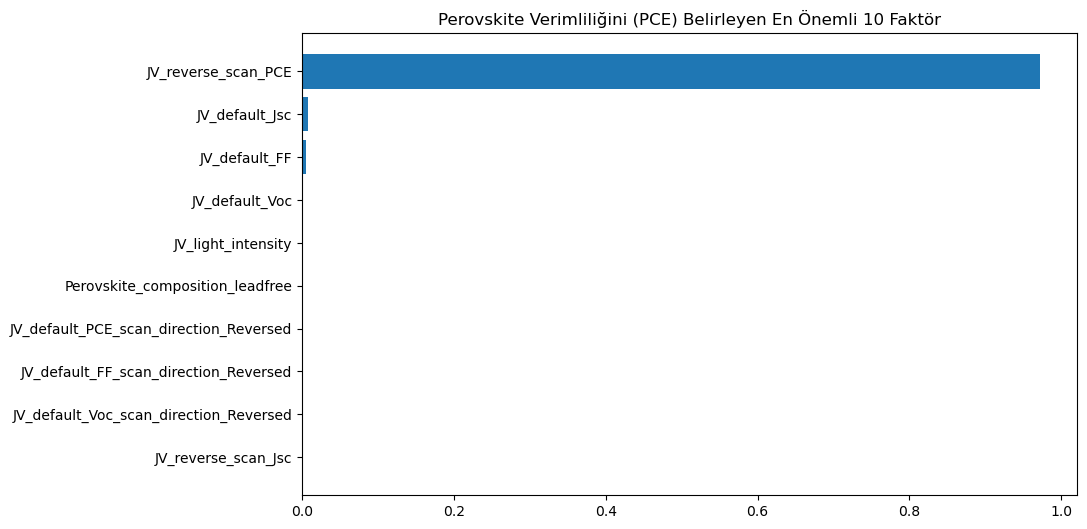

In [15]:
import matplotlib.pyplot as plt

# En önemli 10 özelliği bul
importances = model.feature_importances_
feature_names = X.columns
feature_importance_df = pd.DataFrame({'Özellik': feature_names, 'Önem': importances}).sort_values(by='Önem', ascending=False)

# Grafik olarak göster
plt.figure(figsize=(10,6))
plt.barh(feature_importance_df['Özellik'].head(10), feature_importance_df['Önem'].head(10))
plt.gca().invert_yaxis()
plt.title("Perovskite Verimliliğini (PCE) Belirleyen En Önemli 10 Faktör")
plt.show()

C:\Users\Asus\AppData\Local\Temp\ipykernel_14580\478707357.py:11: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(x='Önem', y='Özellik', data=feature_importance_df.head(15), palette='viridis')


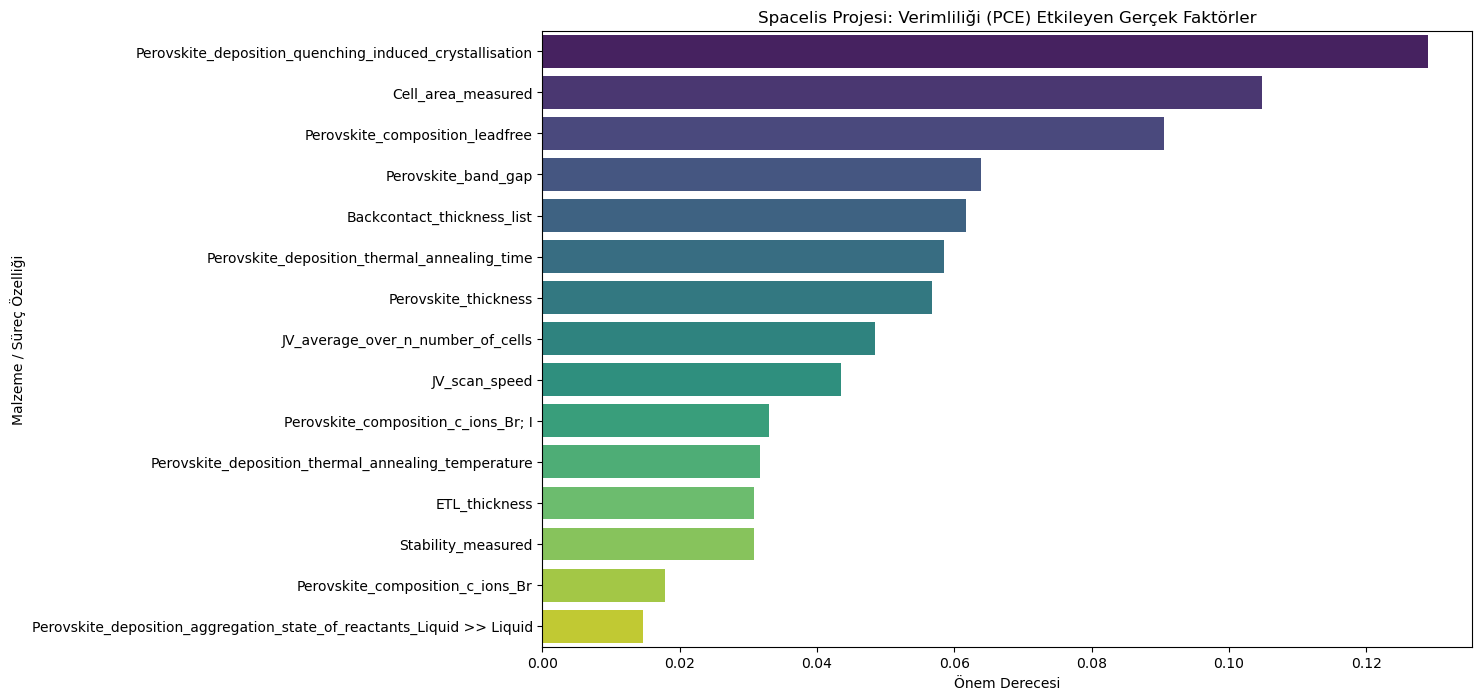

In [17]:
import matplotlib.pyplot as plt
import seaborn as sns

# En önemli 15 özelliği belirle
importances = model.feature_importances_
feature_names = X.columns
feature_importance_df = pd.DataFrame({'Özellik': feature_names, 'Önem': importances}).sort_values(by='Önem', ascending=False)

# Grafikleştir
plt.figure(figsize=(12,8))
sns.barplot(x='Önem', y='Özellik', data=feature_importance_df.head(15), palette='viridis')
plt.title("Spacelis Projesi: Verimliliği (PCE) Etkileyen Gerçek Faktörler")
plt.xlabel("Önem Derecesi")
plt.ylabel("Malzeme / Süreç Özelliği")
plt.show()

In [18]:
df_model_ready.to_csv('spacelis_model_hazir_veri.csv', index=False)

In [19]:
import joblib

# Eğittiğin 'model' nesnesini spacelis_model.pkl adıyla kaydeder
joblib.dump(model, 'spacelis_random_forest_model.pkl')

['spacelis_random_forest_model.pkl']

In [20]:
import pandas as pd
import joblib

# 1. Kaydettiğimiz veriyi geri oku bakalım sağlam mı?
test_df = pd.read_csv('spacelis_model_hazir_veri.csv')
print(f"Veri kontrolü: {test_df.shape} boyutunda veri başarıyla yüklendi.")

# 2. Kaydettiğimiz modeli geri yükle bakalım çalışıyor mu?
yuklenen_model = joblib.load('spacelis_random_forest_model.pkl')
print("Model kontrolü: Kaydedilen model başarıyla hafızaya alındı!")

Veri kontrolü: (41519, 223) boyutunda veri başarıyla yüklendi.
Model kontrolü: Kaydedilen model başarıyla hafızaya alındı!
